# Limpieza y preparación de datos

En este notebook se realizará la limpieza inicial del dataset **Cardiovascular Disease Dataset** antes de aplicar feature engineering y modelado supervisado.

A partir del análisis exploratorio se identificó que el dataset no presenta valores nulos ni duplicados exactos, pero sí contiene valores fisiológicamente inconsistentes en variables como altura, peso y presión arterial.

Durante esta etapa se realizarán las siguientes acciones:

* Crear una copia del dataset original para trabajar de forma segura.
* Eliminar la variable `id`, ya que es solo un identificador.
* Convertir la edad de días a años para mejorar su interpretación.
* Detectar registros con valores fisiológicamente no plausibles.
* Filtrar inconsistencias en altura, peso, presión sistólica y presión diastólica.
* Verificar que la limpieza no altere significativamente la distribución de la variable objetivo `cardio`.
* Generar un dataset limpio para las siguientes fases del proyecto.

El objetivo de esta etapa es mejorar la calidad de los datos y evitar que errores de registro afecten el entrenamiento de los modelos predictivos.


In [1]:
# Librerías principales
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

In [2]:
# Cargar dataset original
df = pd.read_csv("cardio_train.csv", sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.00,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.00,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.00,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.00,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.00,100,60,1,1,0,0,0,0


In [3]:
# Crear copia del dataset para limpieza
df_clean = df.copy()

# Verificar copia
df_clean.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.00,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.00,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.00,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.00,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.00,100,60,1,1,0,0,0,0


In [4]:
# Columnas del dataset
df_clean.columns.tolist()

['id',
 'age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio']

## Revision de nulos y duplicados

In [5]:
# Valores faltantes por columna
missing_values = df_clean.isnull().sum()

missing_values

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [6]:
# Cantidad de duplicados exactos
duplicados_exactos = df_clean.duplicated().sum()

print(f"Duplicados exactos: {duplicados_exactos}")

Duplicados exactos: 0


## Eliminar columnas que no sirven


In [7]:
# Eliminar la variable id porque solo es un identificador
df_clean = df_clean.drop(columns=["id"])

df_clean.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.00,110,80,1,1,0,0,1,0
1,20228,1,156,85.00,140,90,3,1,0,0,1,1
2,18857,1,165,64.00,130,70,3,1,0,0,0,1
3,17623,2,169,82.00,150,100,1,1,0,0,1,1
4,17474,1,156,56.00,100,60,1,1,0,0,0,0


## Conversion de variable edad


In [8]:
# Convertir la edad de días a años
df_clean["age_years"] = (df_clean["age"] / 365).astype(int)

# Eliminar la variable age original
df_clean = df_clean.drop(columns=["age"])

df_clean.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,168,62.00,110,80,1,1,0,0,1,0,50
1,1,156,85.00,140,90,3,1,0,0,1,1,55
2,1,165,64.00,130,70,3,1,0,0,0,1,51
3,2,169,82.00,150,100,1,1,0,0,1,1,48
4,1,156,56.00,100,60,1,1,0,0,0,0,47


In [9]:
# Reordenar columnas para facilitar la lectura
df_clean = df_clean[
    [
        "age_years",
        "gender",
        "height",
        "weight",
        "ap_hi",
        "ap_lo",
        "cholesterol",
        "gluc",
        "smoke",
        "alco",
        "active",
        "cardio"
    ]
]

df_clean.head()

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.00,110,80,1,1,0,0,1,0
1,55,1,156,85.00,140,90,3,1,0,0,1,1
2,51,1,165,64.00,130,70,3,1,0,0,0,1
3,48,2,169,82.00,150,100,1,1,0,0,1,1
4,47,1,156,56.00,100,60,1,1,0,0,0,0


## Inconsistencias y outlier

 Diferencia entre outlier e inconsistencia

| Tipo de valor | Descripción | Decisión |
|---|---|---|
| Outlier posible | Valor extremo, poco frecuente, pero que podría ser real | Se conserva |
| Inconsistencia | Valor imposible, negativo, demasiado irreal o que no tiene sentido fisiológico | Se filtra o elimina |

 Criterios definidos

| Variable | Criterio de revisión | Justificación |
|---|---|---|
| `height` | Mantener valores entre 120 cm y 220 cm | El dataset corresponde a población adulta. Alturas fuera de este rango probablemente son errores o casos demasiado atípicos para este análisis. |
| `weight` | Mantener valores entre 30 kg y 200 kg | Se conserva un rango amplio para no eliminar pesos extremos que podrían ser reales, pero se excluyen valores demasiado bajos o demasiado altos. |
| `ap_hi` | Mantener valores entre 70 y 250 mmHg | Se permite presión sistólica muy alta porque puede representar casos graves, pero se excluyen valores negativos, demasiado bajos o extremadamente irreales. |
| `ap_lo` | Mantener valores entre 40 y 150 mmHg | Se permite presión diastólica elevada, pero se excluyen valores negativos, demasiado bajos o extremadamente irreales. |
| `ap_hi` y `ap_lo` | Mantener registros donde `ap_hi > ap_lo` | La presión sistólica debe ser mayor que la presión diastólica. Si no se cumple, el registro no tiene sentido fisiológico. |


In [10]:
# Criterios para detectar valores que probablemente son errores de registro

criterios_inconsistencias = {
    "Altura menor a 120 cm": df_clean["height"] < 120,
    "Altura mayor a 220 cm": df_clean["height"] > 220,
    "Peso menor a 30 kg": df_clean["weight"] < 30,
    "Peso mayor a 200 kg": df_clean["weight"] > 200,
    "Presión sistólica menor a 70": df_clean["ap_hi"] < 70,
    "Presión sistólica mayor a 250": df_clean["ap_hi"] > 250,
    "Presión diastólica menor a 40": df_clean["ap_lo"] < 40,
    "Presión diastólica mayor a 150": df_clean["ap_lo"] > 150,
    "Presión sistólica menor o igual que diastólica": df_clean["ap_hi"] <= df_clean["ap_lo"]
}

# Crear tabla resumen
inconsistencias_df = pd.DataFrame({
    "Criterio": criterios_inconsistencias.keys(),
    "Cantidad de registros": [condicion.sum() for condicion in criterios_inconsistencias.values()]
})

inconsistencias_df["Porcentaje (%)"] = (
    inconsistencias_df["Cantidad de registros"] / len(df_clean)
) * 100

inconsistencias_df

,Criterio,Cantidad de registros,Porcentaje (%)
0,Altura menor a 120 cm,52,0.07
1,Altura mayor a 220 cm,1,0.00
2,Peso menor a 30 kg,7,0.01
3,Peso mayor a 200 kg,0,0.00
4,Presión sistólica menor a 70,189,0.27
5,Presión sistólica mayor a 250,40,0.06
6,Presión diastólica menor a 40,59,0.08
7,Presión diastólica mayor a 150,975,1.39
8,Presión sistólica menor o igual que diastólica,1236,1.77


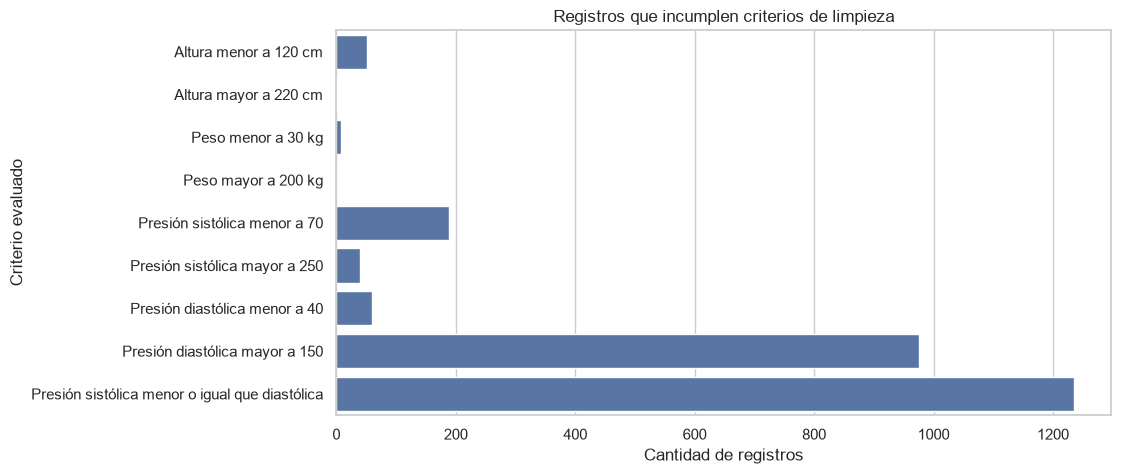

In [11]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=inconsistencias_df,
    x="Cantidad de registros",
    y="Criterio"
)

plt.title("Registros que incumplen criterios de limpieza")
plt.xlabel("Cantidad de registros")
plt.ylabel("Criterio evaluado")

plt.show()

In [12]:
# Condición general: registros que incumplen al menos uno de los criterios
condicion_inconsistente = (
    (df_clean["height"] < 120) |
    (df_clean["height"] > 220) |
    (df_clean["weight"] < 30) |
    (df_clean["weight"] > 200) |
    (df_clean["ap_hi"] < 70) |
    (df_clean["ap_hi"] > 250) |
    (df_clean["ap_lo"] < 40) |
    (df_clean["ap_lo"] > 150) |
    (df_clean["ap_hi"] <= df_clean["ap_lo"])
)

total_inconsistentes = condicion_inconsistente.sum()
porcentaje_inconsistentes = (total_inconsistentes / len(df_clean)) * 100

print(f"Registros con al menos una inconsistencia: {total_inconsistentes}")
print(f"Porcentaje del dataset: {porcentaje_inconsistentes:.2f}%")

Registros con al menos una inconsistencia: 1390
Porcentaje del dataset: 1.99%


In [13]:
# Mostrar algunos registros que incumplen al menos un criterio
df_clean[condicion_inconsistente].head(10)

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
224,59,2,76,55.00,120,80,1,1,0,0,1,0
228,47,2,183,98.00,160,1100,1,2,1,0,1,1
241,60,2,157,60.00,160,1000,2,1,0,0,0,1
260,49,1,150,83.00,140,800,1,1,0,0,1,1
329,64,1,176,63.00,160,1000,2,2,0,0,0,1
345,51,1,154,81.00,140,1000,2,1,0,0,1,1
418,45,1,157,72.00,150,30,1,1,0,0,1,1
473,41,1,150,95.00,150,1033,1,1,0,0,1,1
474,52,1,156,65.00,120,150,2,1,0,0,1,0
559,55,2,173,101.00,200,1000,1,1,0,0,1,1


In [14]:
# Distribución de cardio en registros inconsistentes
cardio_inconsistentes = df_clean.loc[condicion_inconsistente, "cardio"].value_counts().sort_index()

cardio_inconsistentes

cardio
0     352
1    1038
Name: count, dtype: int64

In [15]:
# Porcentaje de cardio en registros inconsistentes
cardio_inconsistentes_pct = (
    df_clean.loc[condicion_inconsistente, "cardio"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

cardio_inconsistentes_pct

cardio
0   25.32
1   74.68
Name: proportion, dtype: float64

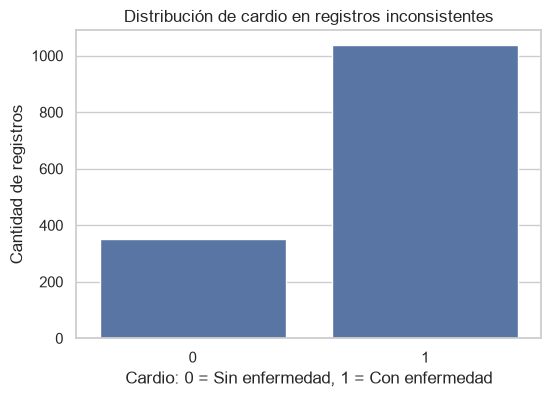

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean.loc[condicion_inconsistente],
    x="cardio"
)

plt.title("Distribución de cardio en registros inconsistentes")
plt.xlabel("Cardio: 0 = Sin enfermedad, 1 = Con enfermedad")
plt.ylabel("Cantidad de registros")

plt.show()

La limpieza se enfocará principalmente en los errores claros, evitando eliminar información útil asociada a pacientes con enfermedad cardiovascular.

In [17]:
# Clasificación más detallada de inconsistencias

errores_claros = {
    "Presión sistólica menor o igual a 0": df_clean["ap_hi"] <= 0,
    "Presión diastólica menor o igual a 0": df_clean["ap_lo"] <= 0,
    "Presión sistólica extremadamente alta (>300)": df_clean["ap_hi"] > 300,
    "Presión diastólica extremadamente alta (>300)": df_clean["ap_lo"] > 300,
    "Presión sistólica menor o igual que diastólica": df_clean["ap_hi"] <= df_clean["ap_lo"]
}

errores_claros_df = pd.DataFrame({
    "Criterio": errores_claros.keys(),
    "Cantidad de registros": [condicion.sum() for condicion in errores_claros.values()]
})

errores_claros_df["Porcentaje (%)"] = (
    errores_claros_df["Cantidad de registros"] / len(df_clean)
) * 100

errores_claros_df

,Criterio,Cantidad de registros,Porcentaje (%)
0,Presión sistólica menor o igual a 0,7,0.01
1,Presión diastólica menor o igual a 0,22,0.03
2,Presión sistólica extremadamente alta (>300),40,0.06
3,Presión diastólica extremadamente alta (>300),953,1.36
4,Presión sistólica menor o igual que diastólica,1236,1.77


In [18]:
condicion_error_claro = (
    (df_clean["ap_hi"] <= 0) |
    (df_clean["ap_lo"] <= 0) |
    (df_clean["ap_hi"] > 300) |
    (df_clean["ap_lo"] > 300) |
    (df_clean["ap_hi"] <= df_clean["ap_lo"])
)

total_error_claro = condicion_error_claro.sum()
porcentaje_error_claro = (total_error_claro / len(df_clean)) * 100

print(f"Registros con error claro: {total_error_claro}")
print(f"Porcentaje del dataset: {porcentaje_error_claro:.2f}%")

Registros con error claro: 1291
Porcentaje del dataset: 1.84%


In [19]:
df_clean.loc[condicion_error_claro, "cardio"].value_counts().sort_index()

cardio
0    303
1    988
Name: count, dtype: int64

In [20]:
df_clean.loc[condicion_error_claro, "cardio"].value_counts(normalize=True).sort_index() * 100

cardio
0   23.47
1   76.53
Name: proportion, dtype: float64

Decisión sobre errores claros

La revisión detallada muestra que existen **1.291 registros** con errores claros, equivalentes al **1.84%** del dataset. Estos errores se concentran principalmente en variables de presión arterial, especialmente en casos donde la presión diastólica supera valores extremadamente altos o donde la presión sistólica es menor o igual que la diastólica.

Aunque estos registros se concentran mayormente en la clase `cardio = 1`, no se consideran valores extremos útiles para el modelo, sino posibles errores de registro. Mantenerlos podría generar relaciones artificiales y afectar la capacidad de generalización del modelo.

Por esta razón, se decide eliminar únicamente los registros con errores claros de presión arterial. No se eliminarán todos los outliers, ya que algunos valores extremos pueden representar casos reales y aportar información relevante al análisis.

In [21]:
# Eliminar registros con errores claros
df_clean = df_clean[~condicion_error_claro].copy()

# Verificar dimensiones después de eliminar errores claros
df_clean.shape

(68709, 12)

In [22]:
# Comparar distribución de cardio después de eliminar errores claros
df_clean["cardio"].value_counts().sort_index()

cardio
0    34718
1    33991
Name: count, dtype: int64

In [23]:
df_clean["cardio"].value_counts(normalize=True).sort_index() * 100

cardio
0   50.53
1   49.47
Name: proportion, dtype: float64

In [24]:
# Recalcular criterios después de eliminar errores claros

criterios_restantes = {
    "Altura menor a 120 cm": df_clean["height"] < 120,
    "Altura mayor a 220 cm": df_clean["height"] > 220,
    "Peso menor a 30 kg": df_clean["weight"] < 30,
    "Peso mayor a 200 kg": df_clean["weight"] > 200,
    "Presión sistólica menor a 70": df_clean["ap_hi"] < 70,
    "Presión sistólica mayor a 250": df_clean["ap_hi"] > 250,
    "Presión diastólica menor a 40": df_clean["ap_lo"] < 40,
    "Presión diastólica mayor a 150": df_clean["ap_lo"] > 150,
    "Presión sistólica menor o igual que diastólica": df_clean["ap_hi"] <= df_clean["ap_lo"]
}

inconsistencias_restantes_df = pd.DataFrame({
    "Criterio": criterios_restantes.keys(),
    "Cantidad de registros": [condicion.sum() for condicion in criterios_restantes.values()]
})

inconsistencias_restantes_df["Porcentaje (%)"] = (
    inconsistencias_restantes_df["Cantidad de registros"] / len(df_clean)
) * 100

inconsistencias_restantes_df

,Criterio,Cantidad de registros,Porcentaje (%)
0,Altura menor a 120 cm,50,0.07
1,Altura mayor a 220 cm,1,0.00
2,Peso menor a 30 kg,6,0.01
3,Peso mayor a 200 kg,0,0.00
4,Presión sistólica menor a 70,3,0.00
5,Presión sistólica mayor a 250,0,0.00
6,Presión diastólica menor a 40,37,0.05
7,Presión diastólica mayor a 150,5,0.01
8,Presión sistólica menor o igual que diastólica,0,0.00


In [25]:
# Registros que todavía incumplen algún criterio amplio de revisión
condicion_restante = (
    (df_clean["height"] < 120) |
    (df_clean["height"] > 220) |
    (df_clean["weight"] < 30) |
    (df_clean["weight"] > 200) |
    (df_clean["ap_hi"] < 70) |
    (df_clean["ap_hi"] > 250) |
    (df_clean["ap_lo"] < 40) |
    (df_clean["ap_lo"] > 150) |
    (df_clean["ap_hi"] <= df_clean["ap_lo"])
)

total_restantes = condicion_restante.sum()
porcentaje_restantes = (total_restantes / len(df_clean)) * 100

print(f"Registros restantes con algún criterio incumplido: {total_restantes}")
print(f"Porcentaje del dataset limpio parcial: {porcentaje_restantes:.2f}%")

Registros restantes con algún criterio incumplido: 99
Porcentaje del dataset limpio parcial: 0.14%


In [26]:
df_clean[condicion_restante].head(10)

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
224,59,2,76,55.00,120,80,1,1,0,0,1,0
418,45,1,157,72.00,150,30,1,1,0,0,1,1
3420,39,1,100,70.00,100,70,1,1,0,0,1,0
4781,51,1,158,74.00,200,170,1,1,0,0,1,1
4981,62,2,173,74.00,220,160,2,2,0,0,1,1
5333,57,1,164,102.00,120,30,2,1,0,0,1,0
6486,58,1,250,86.00,140,100,3,1,0,0,1,1
6737,45,1,156,61.00,150,10,1,1,0,0,0,1
7116,56,2,117,78.00,150,90,1,1,1,0,1,1
7598,40,2,70,72.00,120,8,1,1,0,0,1,0


In [27]:
# Crear IMC provisional para revisar coherencia entre altura y peso
df_clean["bmi_temp"] = df_clean["weight"] / ((df_clean["height"] / 100) ** 2)

# Revisar registros con altura o peso extremo
casos_altura_peso_extremos = df_clean[
    (df_clean["height"] < 120) |
    (df_clean["height"] > 220) |
    (df_clean["weight"] < 30) |
    (df_clean["weight"] > 200)
].copy()

casos_altura_peso_extremos[
    ["age_years", "gender", "height", "weight", "bmi_temp", "cardio"]
].sort_values("height").head(20)

,age_years,gender,height,weight,bmi_temp,cardio
22723,64,1,55,81.00,267.77,1
66643,51,1,57,61.00,187.75,1
64115,50,1,59,57.60,165.47,0
29157,52,1,60,69.00,191.67,0
27603,57,1,64,61.00,148.93,0
44490,52,1,65,60.00,142.01,0
33607,53,2,65,72.00,170.41,0
14323,60,1,67,57.00,126.98,1
50789,39,2,67,60.00,133.66,0
53344,56,2,67,80.00,178.21,1


In [28]:
casos_altura_peso_extremos[
    ["age_years", "gender", "height", "weight", "bmi_temp", "cardio"]
].sort_values("bmi_temp").head(20)

,age_years,gender,height,weight,bmi_temp,cardio
33817,59,2,178,11.00,3.47,1
29488,55,2,177,22.00,7.02,0
60188,59,1,162,21.00,8.00,1
26806,63,1,157,23.00,9.33,0
60699,51,1,171,29.00,9.92,1
6486,58,1,250,86.00,13.76,1
34276,40,2,128,28.00,17.09,0
59960,58,2,117,70.00,51.14,1
29735,47,1,109,64.00,53.87,1
46043,51,1,111,69.00,56.00,1


In [29]:
# Revisar todos los casos de altura/peso extremos ordenados por altura
casos_altura_peso_extremos[
    ["age_years", "gender", "height", "weight", "bmi_temp", "cardio"]
].sort_values("height")

,age_years,gender,height,weight,bmi_temp,cardio
22723,64,1,55,81.00,267.77,1
66643,51,1,57,61.00,187.75,1
64115,50,1,59,57.60,165.47,0
29157,52,1,60,69.00,191.67,0
27603,57,1,64,61.00,148.93,0
44490,52,1,65,60.00,142.01,0
33607,53,2,65,72.00,170.41,0
14323,60,1,67,57.00,126.98,1
50789,39,2,67,60.00,133.66,0
53344,56,2,67,80.00,178.21,1


In [30]:
# Ver cuántos casos tienen IMC temporal extremadamente fuera de rango
bmi_extremo = (df_clean["bmi_temp"] < 10) | (df_clean["bmi_temp"] > 80)

print("Casos con IMC temporal extremo:", bmi_extremo.sum())
print("Porcentaje:", bmi_extremo.sum() / len(df_clean) * 100)

Casos con IMC temporal extremo: 37
Porcentaje: 0.053850296176628974


In [31]:
df_clean[bmi_extremo][
    ["age_years", "gender", "height", "weight", "bmi_temp", "cardio"]
].sort_values("bmi_temp")

,age_years,gender,height,weight,bmi_temp,cardio
33817,59,2,178,11.00,3.47,1
29488,55,2,177,22.00,7.02,0
60188,59,1,162,21.00,8.00,1
26806,63,1,157,23.00,9.33,0
60699,51,1,171,29.00,9.92,1
12435,60,1,137,161.00,85.78,1
17074,58,1,100,86.00,86.00,1
28897,51,1,110,105.00,86.78,1
224,59,2,76,55.00,95.22,0
15366,47,1,125,167.00,106.88,1


In [32]:
# Eliminar registros con IMC temporal extremo
df_clean = df_clean[~bmi_extremo].copy()

# Verificar dimensiones después de eliminar IMC extremo
df_clean.shape

(68672, 13)

In [33]:
# Distribución final de cardio después de eliminar IMC extremo
df_clean["cardio"].value_counts().sort_index()

cardio
0    34699
1    33973
Name: count, dtype: int64

In [34]:
# Eliminar variable temporal usada solo para revisión
df_clean = df_clean.drop(columns=["bmi_temp"])

Decisión sobre IMC temporal extremo

Se identificaron 37 registros con valores de IMC temporal extremadamente altos o bajos, generados por combinaciones poco coherentes entre altura y peso. Estos casos representan únicamente el 0.054% del dataset.

No se eliminaron registros solo por presentar altura baja o peso extremo de manera aislada. La decisión se basó en la combinación entre altura y peso, ya que un IMC temporal extremadamente alto puede indicar errores de registro que afectarían directamente el feature engineering posterior.

Por esta razón, se eliminaron los registros con IMC temporal extremo antes de crear la variable definitiva de IMC.

In [35]:
# Revisión final de criterios después de la limpieza

criterios_finales = {
    "Altura menor a 120 cm": df_clean["height"] < 120,
    "Altura mayor a 220 cm": df_clean["height"] > 220,
    "Peso menor a 30 kg": df_clean["weight"] < 30,
    "Peso mayor a 200 kg": df_clean["weight"] > 200,
    "Presión sistólica menor a 70": df_clean["ap_hi"] < 70,
    "Presión sistólica mayor a 250": df_clean["ap_hi"] > 250,
    "Presión diastólica menor a 40": df_clean["ap_lo"] < 40,
    "Presión diastólica mayor a 150": df_clean["ap_lo"] > 150,
    "Presión sistólica menor o igual que diastólica": df_clean["ap_hi"] <= df_clean["ap_lo"]
}

revision_final_df = pd.DataFrame({
    "Criterio": criterios_finales.keys(),
    "Cantidad de registros": [condicion.sum() for condicion in criterios_finales.values()]
})

revision_final_df["Porcentaje (%)"] = (
    revision_final_df["Cantidad de registros"] / len(df_clean)
) * 100

revision_final_df

,Criterio,Cantidad de registros,Porcentaje (%)
0,Altura menor a 120 cm,21,0.03
1,Altura mayor a 220 cm,1,0.00
2,Peso menor a 30 kg,1,0.00
3,Peso mayor a 200 kg,0,0.00
4,Presión sistólica menor a 70,3,0.00
5,Presión sistólica mayor a 250,0,0.00
6,Presión diastólica menor a 40,36,0.05
7,Presión diastólica mayor a 150,5,0.01
8,Presión sistólica menor o igual que diastólica,0,0.00


In [36]:
# Crear condición final de registros que aún incumplen algún criterio
condicion_revision_final = (
    (df_clean["height"] < 120) |
    (df_clean["height"] > 220) |
    (df_clean["weight"] < 30) |
    (df_clean["weight"] > 200) |
    (df_clean["ap_hi"] < 70) |
    (df_clean["ap_hi"] > 250) |
    (df_clean["ap_lo"] < 40) |
    (df_clean["ap_lo"] > 150) |
    (df_clean["ap_hi"] <= df_clean["ap_lo"])
)

# Ver registros restantes
df_clean[condicion_revision_final].sort_values(["height", "ap_lo"]).head(50)

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
28737,54,1,91,55.00,140,90,1,1,0,0,1,1
56022,58,1,96,59.00,90,60,1,1,0,0,1,1
65302,50,1,99,60.00,90,60,1,1,0,0,1,0
58868,40,2,100,60.00,100,60,1,1,0,0,1,0
3420,39,1,100,70.00,100,70,1,1,0,0,1,0
37388,60,1,105,72.00,120,70,1,3,0,0,1,0
64787,64,1,105,80.00,130,90,1,1,0,0,1,1
39543,40,1,108,70.00,140,90,1,1,0,0,1,1
29735,47,1,109,64.00,140,80,3,1,0,0,1,1
41807,63,1,109,68.00,120,80,1,1,0,0,1,1


In [37]:
df_clean[df_clean["height"] < 120][
    ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
].sort_values("height")

,age_years,gender,height,weight,ap_hi,ap_lo,cardio
28737,54,1,91,55.00,140,90,1
56022,58,1,96,59.00,90,60,1
65302,50,1,99,60.00,90,60,0
58868,40,2,100,60.00,100,60,0
3420,39,1,100,70.00,100,70,0
37388,60,1,105,72.00,120,70,0
64787,64,1,105,80.00,130,90,1
39543,40,1,108,70.00,140,90,1
41807,63,1,109,68.00,120,80,1
29735,47,1,109,64.00,140,80,1


In [38]:
df_clean[df_clean["height"] > 220][
    ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
]

,age_years,gender,height,weight,ap_hi,ap_lo,cardio
6486,58,1,250,86.00,140,100,1


In [39]:
# Revisar cuántos registros se eliminarían por altura extrema
condicion_altura_extrema = (
    (df_clean["height"] < 100) 
)

print("Registros con altura extrema a eliminar:", condicion_altura_extrema.sum())
print("Porcentaje:", condicion_altura_extrema.sum() / len(df_clean) * 100)

df_clean[condicion_altura_extrema][
    ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
].sort_values("height")

Registros con altura extrema a eliminar: 3
Porcentaje: 0.004368592730661696


,age_years,gender,height,weight,ap_hi,ap_lo,cardio
28737,54,1,91,55.00,140,90,1
56022,58,1,96,59.00,90,60,1
65302,50,1,99,60.00,90,60,0


In [40]:
# Eliminar registros con altura extrema
df_clean = df_clean[~condicion_altura_extrema].copy()

df_clean.shape

(68669, 12)

Se eliminaron únicamente los registros con altura extremadamente baja

In [41]:
df_clean[df_clean["weight"] < 30][
    ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
]

,age_years,gender,height,weight,ap_hi,ap_lo,cardio
34276,40,2,128,28.00,120,80,0


In [42]:
df_clean[df_clean["ap_hi"] < 70][
    ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
]

,age_years,gender,height,weight,ap_hi,ap_lo,cardio
13755,43,1,157,73.00,60,40,0
26513,52,1,157,69.00,16,10,1
52851,48,2,164,64.00,24,20,1


In [43]:
condicion_ap_hi_extrema = df_clean["ap_hi"] < 40

df_clean[condicion_ap_hi_extrema][
    ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
]

,age_years,gender,height,weight,ap_hi,ap_lo,cardio
26513,52,1,157,69.00,16,10,1
52851,48,2,164,64.00,24,20,1


In [44]:
# Eliminar registros con ap_hi menor a 40
df_clean = df_clean[~condicion_ap_hi_extrema].copy()

# Verificar dimensiones después del filtro
df_clean.shape

(68667, 12)

In [45]:
df_clean[df_clean["ap_lo"] < 40][
    ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
].sort_values("ap_lo")

,age_years,gender,height,weight,ap_hi,ap_lo,cardio
35140,57,1,146,55.00,130,1,0
28065,55,1,161,52.00,90,6,0
68568,42,1,163,71.00,110,6,0
19075,54,2,168,68.00,110,7,0
18898,48,1,171,68.00,110,7,0
9777,59,1,166,125.00,120,8,1
38599,49,2,165,64.00,120,9,0
10106,50,1,152,50.00,150,10,1
43307,62,1,151,58.00,170,10,1
37169,39,1,165,60.00,170,10,0


In [46]:
# Revisar distribución de cardio en ap_lo menor a 30
condicion_ap_lo_muy_baja = df_clean["ap_lo"] < 30

df_clean.loc[condicion_ap_lo_muy_baja, "cardio"].value_counts().sort_index()

cardio
0    15
1    13
Name: count, dtype: int64

In [47]:
# Eliminar registros con ap_lo menor a 30
df_clean = df_clean[~condicion_ap_lo_muy_baja].copy()

# Verificar dimensiones después del filtro
df_clean.shape

(68639, 12)

In [48]:
df_clean[df_clean["ap_lo"] > 150][
    ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
].sort_values("ap_lo")

,age_years,gender,height,weight,ap_hi,ap_lo,cardio
4981,62,2,173,74.00,220,160,1
54987,53,1,169,80.00,200,160,0
4781,51,1,158,74.00,200,170,1
43998,62,2,163,70.00,200,180,1
38022,59,1,161,84.00,196,182,1


In [49]:
# Crear una copia temporal para revisar diferencia entre ap_hi y ap_lo
ap_lo_alta = df_clean[df_clean["ap_lo"] > 150][
    ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
].copy()

ap_lo_alta["diferencia_ap"] = ap_lo_alta["ap_hi"] - ap_lo_alta["ap_lo"]

ap_lo_alta.sort_values("ap_lo")

,age_years,gender,height,weight,ap_hi,ap_lo,cardio,diferencia_ap
4981,62,2,173,74.00,220,160,1,60
54987,53,1,169,80.00,200,160,0,40
4781,51,1,158,74.00,200,170,1,30
43998,62,2,163,70.00,200,180,1,20
38022,59,1,161,84.00,196,182,1,14


In [50]:
# Casos con presión diastólica alta y diferencia baja entre sistólica y diastólica
condicion_ap_lo_alta_sospechosa = (
    (df_clean["ap_lo"] > 150) &
    ((df_clean["ap_hi"] - df_clean["ap_lo"]) < 40)
)

df_clean[condicion_ap_lo_alta_sospechosa][
    ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
]

,age_years,gender,height,weight,ap_hi,ap_lo,cardio
4781,51,1,158,74.00,200,170,1
38022,59,1,161,84.00,196,182,1
43998,62,2,163,70.00,200,180,1


In [51]:
# Eliminar casos de presión diastólica alta con diferencia sistólica-diastólica muy baja
df_clean = df_clean[~condicion_ap_lo_alta_sospechosa].copy()

df_clean.shape

(68636, 12)

In [52]:
criterios_finales = {
    "Altura menor a 100 cm": df_clean["height"] < 100,
    "Altura mayor a 220 cm": df_clean["height"] > 220,
    "Peso menor a 30 kg": df_clean["weight"] < 30,
    "Peso mayor a 200 kg": df_clean["weight"] > 200,
    "Presión sistólica menor a 40": df_clean["ap_hi"] < 40,
    "Presión sistólica mayor a 250": df_clean["ap_hi"] > 250,
    "Presión diastólica menor a 30": df_clean["ap_lo"] < 30,
    "Presión diastólica alta con diferencia baja": (
        (df_clean["ap_lo"] > 150) &
        ((df_clean["ap_hi"] - df_clean["ap_lo"]) < 40)
    ),
    "Presión sistólica menor o igual que diastólica": df_clean["ap_hi"] <= df_clean["ap_lo"]
}

revision_final_df = pd.DataFrame({
    "Criterio": criterios_finales.keys(),
    "Cantidad de registros": [condicion.sum() for condicion in criterios_finales.values()]
})

revision_final_df["Porcentaje (%)"] = (
    revision_final_df["Cantidad de registros"] / len(df_clean)
) * 100

revision_final_df

,Criterio,Cantidad de registros,Porcentaje (%)
0,Altura menor a 100 cm,0,0.00
1,Altura mayor a 220 cm,1,0.00
2,Peso menor a 30 kg,1,0.00
3,Peso mayor a 200 kg,0,0.00
4,Presión sistólica menor a 40,0,0.00
5,Presión sistólica mayor a 250,0,0.00
6,Presión diastólica menor a 30,0,0.00
7,Presión diastólica alta con diferencia baja,0,0.00
8,Presión sistólica menor o igual que diastólica,0,0.00


## Revision final luego de la limpieza

In [53]:
registros_originales = df.shape[0]
registros_limpios = df_clean.shape[0]
registros_eliminados = registros_originales - registros_limpios
porcentaje_eliminado = (registros_eliminados / registros_originales) * 100

print(f"Registros originales: {registros_originales}")
print(f"Registros finales después de limpieza: {registros_limpios}")
print(f"Registros eliminados: {registros_eliminados}")
print(f"Porcentaje eliminado: {porcentaje_eliminado:.2f}%")

Registros originales: 70000
Registros finales después de limpieza: 68636
Registros eliminados: 1364
Porcentaje eliminado: 1.95%


In [54]:
cardio_final = pd.DataFrame({
    "Cantidad": df_clean["cardio"].value_counts().sort_index(),
    "Porcentaje (%)": df_clean["cardio"].value_counts(normalize=True).sort_index() * 100
})

cardio_final

,Cantidad,Porcentaje (%)
cardio,,
0,34683,50.53
1,33953,49.47


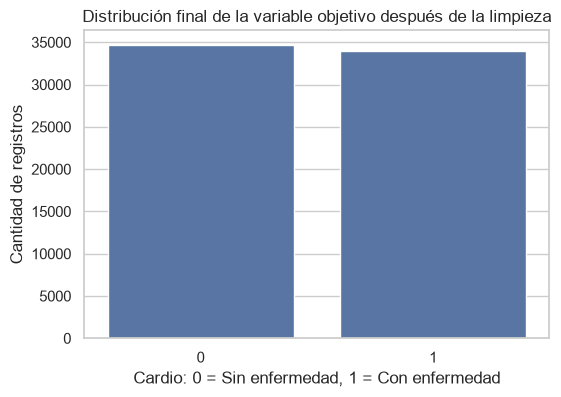

In [55]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df_clean, x="cardio")

plt.title("Distribución final de la variable objetivo después de la limpieza")
plt.xlabel("Cardio: 0 = Sin enfermedad, 1 = Con enfermedad")
plt.ylabel("Cantidad de registros")

plt.show()

In [56]:
df_clean.to_csv("cardio_clean.csv", index=False)

print("Dataset limpio guardado como cardio_clean.csv")

Dataset limpio guardado como cardio_clean.csv


## Conclusión general de la limpieza

Durante la etapa de limpieza se realizaron transformaciones estructurales y filtros sobre registros con valores inconsistentes. Se eliminó la variable `id`, ya que correspondía únicamente a un identificador, y se transformó la edad de días a años mediante la variable `age_years`.

La limpieza no se basó en eliminar todos los valores atípicos, sino en diferenciar entre valores extremos que podrían ser reales y valores con alta probabilidad de error. Por esta razón, se conservaron algunos registros extremos cuando mantenían coherencia con el resto de variables, y se eliminaron únicamente casos con errores claros o combinaciones poco confiables.

Las principales correcciones se realizaron sobre las variables de presión arterial, altura y peso. En presión arterial se eliminaron valores extremadamente bajos, valores incoherentes y combinaciones poco confiables entre presión sistólica y diastólica. En altura y peso se utilizó una revisión más cuidadosa, apoyada en el IMC temporal, para evitar eliminar casos extremos que podían ser posibles.

Después de la limpieza, se verificó que la variable objetivo `cardio` mantiene una distribución equilibrada entre las clases. Esto indica que el proceso no alteró de forma importante el problema de clasificación.

El dataset limpio queda preparado para la siguiente etapa del proyecto: feature engineering.

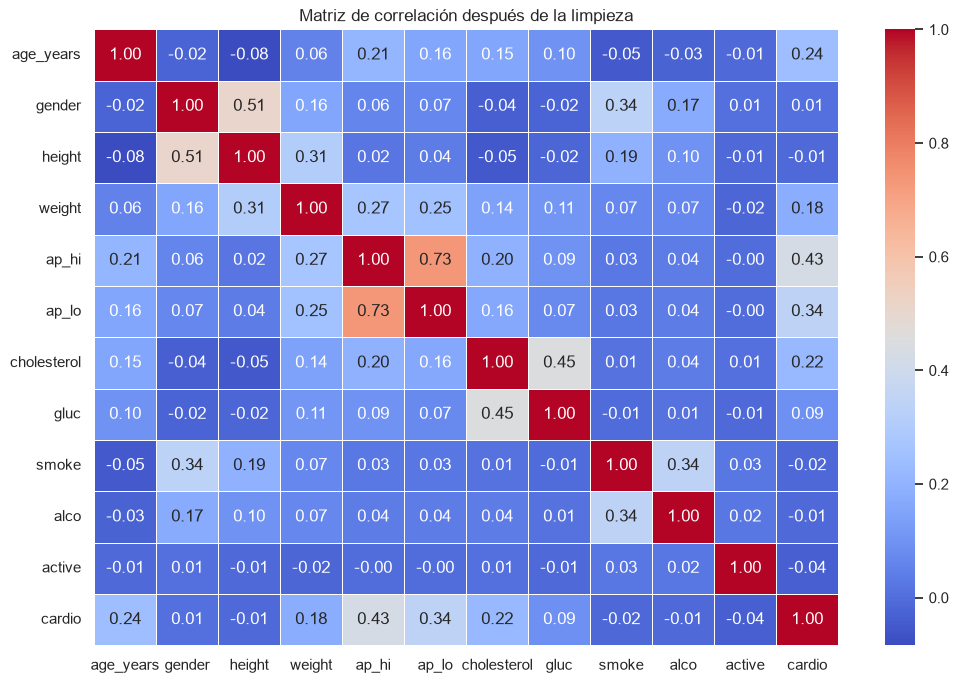

In [57]:
# Matriz de correlación después de la limpieza
correlation_matrix_clean = df_clean.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix_clean,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación después de la limpieza")
plt.show()

In [58]:
# mejora de limpieza

df_clean_final = pd.read_csv("cardio_clean.csv").copy()

In [59]:
duplicados_antes = df_clean_final.duplicated().sum()

print("Duplicados exactos antes:", duplicados_antes)
print("Filas antes:", df_clean_final.shape[0])

Duplicados exactos antes: 3206
Filas antes: 68636


In [60]:
# Eliminar duplicados exactos
df_clean_final = df_clean_final.drop_duplicates().copy()

# Reiniciar índice
df_clean_final = df_clean_final.reset_index(drop=True)

print("Filas después:", df_clean_final.shape[0])
print("Filas eliminadas por duplicados:", duplicados_antes)

Filas después: 65430
Filas eliminadas por duplicados: 3206


In [61]:
# Revisar filas antes del filtro de rangos
filas_antes_rangos = df_clean_final.shape[0]

# Crear BMI temporal solo para validar rangos físicos
df_clean_final["bmi_temp"] = df_clean_final["weight"] / ((df_clean_final["height"] / 100) ** 2)

# Filtro de plausibilidad física
mask_plausible = (
    df_clean_final["height"].between(130, 210) &
    df_clean_final["weight"].between(35, 180) &
    df_clean_final["ap_hi"].between(80, 220) &
    df_clean_final["ap_lo"].between(40, 130) &
    df_clean_final["bmi_temp"].between(12, 60) &
    (df_clean_final["ap_hi"] > df_clean_final["ap_lo"])
)

# Aplicar filtro
df_clean_final = df_clean_final[mask_plausible].copy()

# Eliminar columna temporal
df_clean_final = df_clean_final.drop(columns=["bmi_temp"])

# Reiniciar índice
df_clean_final = df_clean_final.reset_index(drop=True)

print("Filas antes del filtro de rangos:", filas_antes_rangos)
print("Filas después del filtro de rangos:", df_clean_final.shape[0])
print("Filas eliminadas por rangos:", filas_antes_rangos - df_clean_final.shape[0])

Filas antes del filtro de rangos: 65430
Filas después del filtro de rangos: 65307
Filas eliminadas por rangos: 123


In [62]:
# Ver rangos finales
df_clean_final[["height", "weight", "ap_hi", "ap_lo"]].describe()

,height,weight,ap_hi,ap_lo
count,65307.00,65307.00,65307.00,65307.00
mean,164.43,74.40,126.96,81.37
std,7.96,14.37,16.90,9.55
min,130.00,35.00,80.00,40.00
25%,159.00,65.00,120.00,80.00
50%,165.00,72.00,120.00,80.00
75%,170.00,82.00,140.00,90.00
max,207.00,180.00,220.00,130.00


In [63]:
# Guardar dataset final con variables seleccionadas
df_clean_final.to_csv("cardio_clean.csv", index=False)